In [2]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
filename = 'outgassing_grid_1000000samples_MARCH05_qwsd4.npz'

d = np.load(filename, allow_pickle=False)
print(d.files)  # e.g. ['columns', 'data']

print(d["data"].shape, d["data"].dtype)
df = pd.DataFrame(d["data"], columns=d["columns"])

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)
# pd.set_option("display.max_colwidth", None)
df.head()


['columns', 'data']
(8000000, 17) float64


,FMQ_sat,mH2O_sat,mCO2_sat,mS_sat,FeO_star_wt,T,alphaG_sat,P_tot,x_H2O_atm_input,x_H2_atm_input,x_CO2_atm_input,x_CO_atm_input,x_CH4_atm_input,x_S2_atm_input,x_SO2_atm_input,x_H2S_atm_input,mu_gas_atm_input
0,0.551763,0.001955,0.000082,0.002631,0.159056,1573.15,1.000000e-08,0.00001,0.489175,0.074619,0.006710,0.003019,5.157011e-22,0.000081,0.426390,0.000006,36.665437
1,0.551763,0.001955,0.000082,0.002631,0.159056,1573.15,1.000000e-08,0.00010,0.490675,0.073528,0.006762,0.002989,4.869897e-20,0.000753,0.425238,0.000055,36.662645
2,0.551763,0.001955,0.000082,0.002631,0.159056,1573.15,1.000000e-08,0.00100,0.500580,0.067147,0.007069,0.002797,3.402236e-18,0.004659,0.417349,0.000398,36.593231
3,0.551763,0.001955,0.000082,0.002631,0.159056,1573.15,1.000000e-08,0.01000,0.524417,0.052737,0.007894,0.002341,1.317081e-16,0.013357,0.397581,0.001672,36.351990
4,0.551763,0.001955,0.000082,0.002631,0.159056,1573.15,1.000000e-08,0.10000,0.550380,0.036495,0.009355,0.001830,3.249752e-15,0.022434,0.374765,0.004743,36.062029


### Check sampling

Here we just display the sampled parameters to ensure the grid was generated in the way we expect.

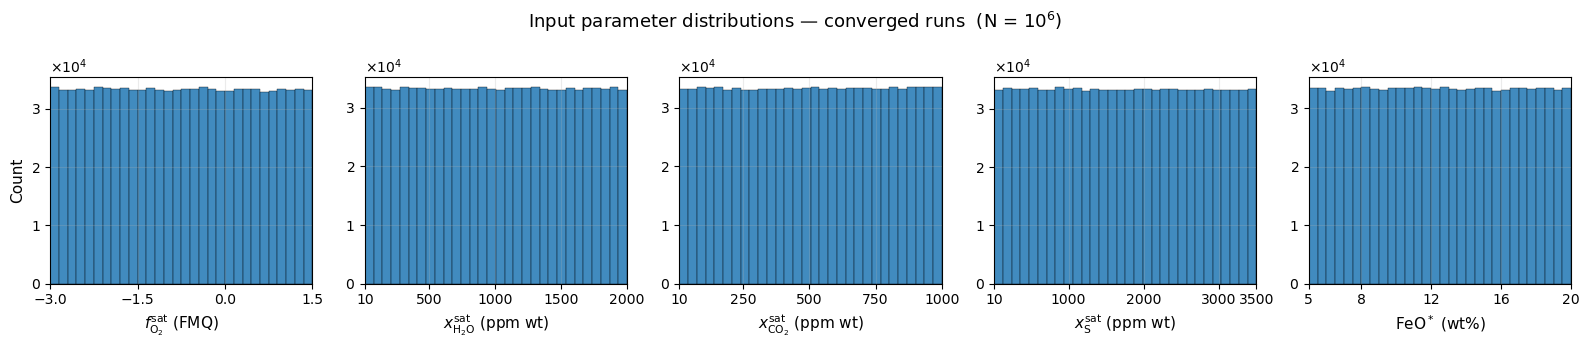

In [4]:
def plot_input_histograms(df, status='converged', color='tab:blue',
                          filename='figures/input_histograms.pdf'):
    import os
    from matplotlib.ticker import MaxNLocator

    df_plot = df.copy()
    df_plot.columns = [str(c) for c in df_plot.columns]

    # (column, xlabel, scale, lo, hi)
    param_cfg = [
        ('FMQ_sat',     r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ (FMQ)',     1.0,  -3.0,  1.5),
        ('mH2O_sat',    r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$ (ppm wt)', 1e6,  10.0,  2000.0),
        ('mCO2_sat',    r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$ (ppm wt)', 1e6,  10.0,  1000.0),
        ('mS_sat',      r'$x_{\mathrm{S}}^{\mathrm{sat}}$ (ppm wt)',    1e6,  10.0,  3500.0),
        ('FeO_star_wt', r'FeO$^*$ (wt%)',                               100., 5.0,   20.0),
    ]
    param_cfg = [(c, lbl, sc, lo, hi) for c, lbl, sc, lo, hi in param_cfg
                 if c in df_plot.columns]

    model_output_candidates = [
        'mu_gas', 'mu_gas_atm_input',
        'x_H2O_gas', 'x_H2_gas', 'x_CO2_gas', 'x_CO_gas', 'x_CH4_gas',
        'x_S2_gas', 'x_SO2_gas', 'x_H2S_gas',
        'x_H2O_atm_input', 'x_H2_atm_input', 'x_CO2_atm_input', 'x_CO_atm_input',
        'x_CH4_atm_input', 'x_S2_atm_input', 'x_SO2_atm_input', 'x_H2S_atm_input',
    ]
    model_output_cols = [c for c in model_output_candidates if c in df_plot.columns]
    row_unconverged = df_plot[model_output_cols].isna().all(axis=1)

    if status == 'unconverged':
        selected_rows = df_plot.loc[row_unconverged]
        title_status  = 'unconverged'
    else:
        selected_rows = df_plot.loc[~row_unconverged]
        title_status  = 'converged'

    input_cols    = [c for c, *_ in param_cfg]
    selected_runs = selected_rows[input_cols].drop_duplicates()
    N             = len(selected_runs)

    n = len(param_cfg)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5))
    if n == 1:
        axes = [axes]

    for i, (ax, (col, xlabel, scale, lo, hi)) in enumerate(zip(axes, param_cfg)):
        vals = pd.to_numeric(selected_runs[col], errors='coerce').to_numpy(dtype=float) * scale
        vals = vals[np.isfinite(vals)]
        bins = np.linspace(lo, hi, 31)

        ax.hist(vals, bins=bins, color=color, alpha=0.85, edgecolor='black', linewidth=0.3)
        ax.set_xlim(lo, hi)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.grid(alpha=0.25)

        # Build x-ticks: auto interior ticks + force lo and hi as endpoints
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune=None))
        fig.canvas.draw()
        interior = [t for t in ax.get_xticks() if lo < t < hi]
        ax.set_xticks(np.unique([lo] + interior + [hi]))

        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, integer=True, prune='lower'))
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

        if i == 0:
            ax.set_ylabel('Count', fontsize=11)

    # Ensure 0 and top tick labeled on all y-axes
    for ax in axes:
        fig.canvas.draw()
        ylo, yhi = ax.get_ylim()
        ticks = [t for t in ax.get_yticks() if 0 <= t <= yhi]
        if not ticks or ticks[0] != 0:
            ticks = [0] + ticks
        ax.set_yticks(ticks)
        ax.set_ylim(0, yhi)

    exp  = int(np.floor(np.log10(N))) if N > 0 else 0
    coef = N / 10**exp
    N_str = f'$10^{{{exp}}}$' if abs(coef - 1.0) < 0.05 else f'${coef:.1f}\\times10^{{{exp}}}$'

    fig.suptitle(
        f'Input parameter distributions — {title_status} runs  (N = {N_str})',
        fontsize=13, y=0.98
    )
    plt.tight_layout()
    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_input_histograms(df, status='converged', color='tab:blue')


### Visualize all model outputs

Here we look at the composition of volcanic gases throughout the entire sampled range.

/var/folders/rp/1t2jxnf13n73yz7txwmmxsqh0000gn/T/ipykernel_10787/925757781.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


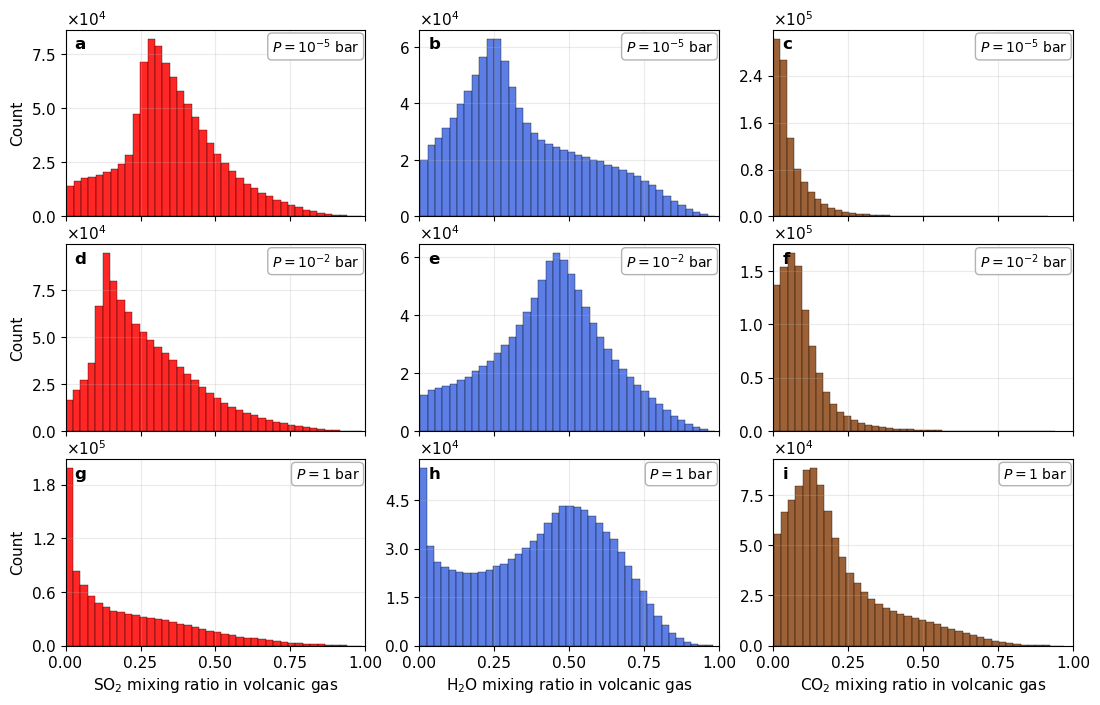

In [36]:
def plot_species_histograms_at_pressure(df,
                                        pressure_slices=(1e-5, 1e-2, 1e0),
                                        pressure_tol=1e-12, bins=40,
                                        filename='figures/species_histograms.pdf'):
    import os
    from matplotlib.ticker import MaxNLocator

    df_plot = df.copy()
    df_plot.columns = [str(c) for c in df_plot.columns]

    pressure_col = 'P_tot' if 'P_tot' in df_plot.columns else 'P'
    so2_col = 'x_SO2_atm_input' if 'x_SO2_atm_input' in df_plot.columns else 'x_SO2_gas'
    h2o_col = 'x_H2O_atm_input' if 'x_H2O_atm_input' in df_plot.columns else 'x_H2O_gas'
    co2_col = 'x_CO2_atm_input' if 'x_CO2_atm_input' in df_plot.columns else 'x_CO2_gas'

    plot_specs = [
        (so2_col, r'SO$_2$ mixing ratio in volcanic gas', 'red'),
        (h2o_col, r'H$_2$O mixing ratio in volcanic gas', 'royalblue'),
        (co2_col, r'CO$_2$ mixing ratio in volcanic gas', 'saddlebrown'),
    ]

    def _P_label(P):
        exp_P = int(np.round(np.log10(P)))
        if exp_P == 0:
            return '$P = 1$ bar'
        return f'$P = 10^{{{exp_P}}}$ bar'

    _lbl_bbox = dict(facecolor='white', edgecolor='0.7', alpha=1.0, boxstyle='round,pad=0.3')
    p_arr = pd.to_numeric(df_plot[pressure_col], errors='coerce').to_numpy(dtype=float)

    fig, axes = plt.subplots(3, 3, figsize=(13, 8),
                             gridspec_kw={'hspace': 0.15, 'wspace': 0.18})

    panel_labels = 'abcdefghi'

    for row, pressure_slice in enumerate(pressure_slices):
        m   = np.isfinite(p_arr) & np.isclose(p_arr, pressure_slice, rtol=0.0, atol=pressure_tol)
        sel = df_plot.loc[m, [so2_col, h2o_col, co2_col]].copy()
        P_str = _P_label(pressure_slice)

        for col_idx, (col, xlabel, color) in enumerate(plot_specs):
            ax   = axes[row, col_idx]
            vals = pd.to_numeric(sel[col], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]

            ax.hist(vals, bins=bins, color=color, alpha=0.85, edgecolor='black', linewidth=0.3)
            ax.set_xlim(0.0, 1.0)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(alpha=0.25)

            ax.yaxis.set_major_locator(MaxNLocator(nbins=4, integer=True, prune='lower'))
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

            if row == 2:
                ax.set_xlabel(xlabel, fontsize=11)
            else:
                ax.set_xticklabels([])

            if col_idx == 0:
                ax.set_ylabel('Count', fontsize=11)

            # Panel label (a, b, c, ...) in top-left
            panel_idx = row * 3 + col_idx
            ax.text(0.03, 0.96, panel_labels[panel_idx],
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=12, fontweight='bold')

            # Pressure label in every panel
            ax.text(0.98, 0.96, P_str, transform=ax.transAxes,
                    ha='right', va='top', fontsize=10, bbox=_lbl_bbox)

    # Ensure 0 is included in ticks on all panels
    for ax in axes.flat:
        fig.canvas.draw()
        ylo, yhi = ax.get_ylim()
        ticks = [t for t in ax.get_yticks() if 0 <= t <= yhi]
        if not ticks or ticks[0] != 0:
            ticks = [0] + ticks
        ax.set_yticks(ticks)
        ax.set_ylim(0, yhi)

    plt.tight_layout()
    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_species_histograms_at_pressure(df, pressure_slices=(1e-5, 1e-2, 1e0))

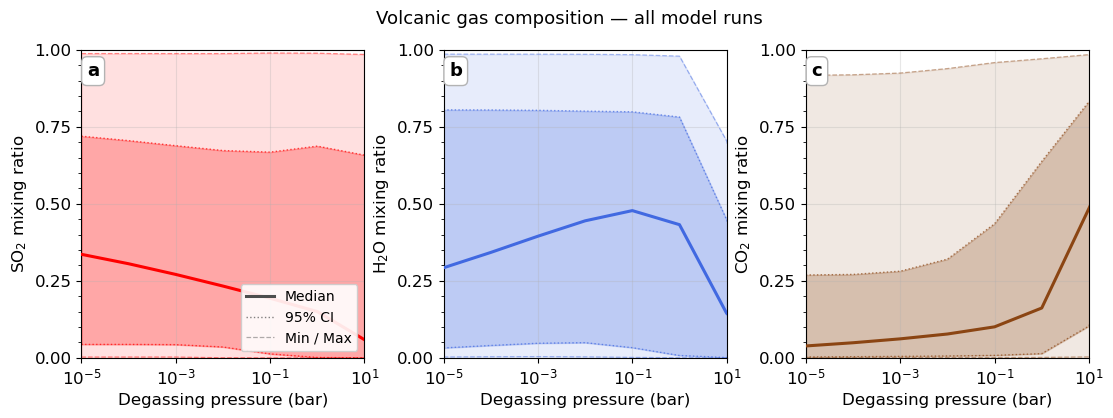

In [6]:
def plot_species_vs_pressure(df, fO2_min=None, fO2_max=None,
                              filename='figures/species_vs_pressure.pdf'):
    """
    3-panel figure: SO2, H2O, CO2 mixing ratios vs degassing pressure
    for all model runs, showing median, 95% CI, and min/max.

    Parameters
    ----------
    df : DataFrame
    fO2_min, fO2_max : float or None
        Optional FMQ range filter.
    filename : str or None
    """
    import os
    from matplotlib.lines import Line2D
    from matplotlib.ticker import AutoMinorLocator

    plt.rcParams.update({'font.size': 12})

    pressure_col = 'P_tot'
    so2_col = 'x_SO2_atm_input'
    h2o_col = 'x_H2O_atm_input'
    co2_col = 'x_CO2_atm_input'

    df_filt = df.copy()
    if fO2_min is not None:
        df_filt = df_filt.loc[df_filt['FMQ_sat'] >= fO2_min]
    if fO2_max is not None:
        df_filt = df_filt.loc[df_filt['FMQ_sat'] <= fO2_max]

    pressures = np.sort(df_filt[pressure_col].dropna().unique())

    panel_cfg = [
        dict(col=so2_col, ylabel='SO$_2$ mixing ratio',  color='red',
             ylim=(0, 1), yticks=np.arange(0, 1.1, 0.25),
             minor_ticks=True, label='a'),
        dict(col=h2o_col, ylabel='H$_2$O mixing ratio',  color='royalblue',
             ylim=(0, 1), yticks=np.arange(0, 1.1, 0.25),
             minor_ticks=True, label='b'),
        dict(col=co2_col, ylabel='CO$_2$ mixing ratio',  color='saddlebrown',
             ylim=(0, 1), yticks=np.arange(0, 1.1, 0.25),
             minor_ticks=True, label='c'),
    ]

    # Collect stats per pressure for each species
    for cfg in panel_cfg:
        cfg['P_valid'] = []
        for stat in ('lo', 'med', 'hi', 'p2_5', 'p97_5'):
            cfg[stat] = []

    for P in pressures:
        sub = df_filt.loc[df_filt[pressure_col] == P]
        if len(sub) == 0:
            continue
        any_added = False
        for cfg in panel_cfg:
            vals = sub[cfg['col']].values
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue
            if not any_added:
                for c in panel_cfg:
                    c['P_valid'].append(P)
                any_added = True
            cfg['lo'].append(np.min(vals))
            cfg['med'].append(np.median(vals))
            cfg['hi'].append(np.max(vals))
            cfg['p2_5'].append(np.percentile(vals, 2.5))
            cfg['p97_5'].append(np.percentile(vals, 97.5))

    for cfg in panel_cfg:
        cfg['P_valid'] = np.array(cfg['P_valid'])
        for stat in ('lo', 'med', 'hi', 'p2_5', 'p97_5'):
            cfg[stat] = np.array(cfg[stat])

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False,
                             gridspec_kw={'wspace': 0.28})

    _lbl_bbox = dict(facecolor='white', edgecolor='0.7', alpha=1.0, boxstyle='round,pad=0.3')

    for ax, cfg in zip(axes, panel_cfg):
        P  = cfg['P_valid']
        lo, med, hi = cfg['lo'], cfg['med'], cfg['hi']
        p2_5, p97_5 = cfg['p2_5'], cfg['p97_5']
        c  = cfg['color']

        ax.fill_between(P, lo, hi,       alpha=0.12, color=c)
        ax.plot(P, lo,    color=c, lw=0.9, ls='--', alpha=0.45)
        ax.plot(P, hi,    color=c, lw=0.9, ls='--', alpha=0.45)
        ax.fill_between(P, p2_5, p97_5,  alpha=0.25, color=c)
        ax.plot(P, p2_5,  color=c, lw=1.0, ls=':', alpha=0.7)
        ax.plot(P, p97_5, color=c, lw=1.0, ls=':', alpha=0.7)
        ax.plot(P, med,   color=c, lw=2.2, zorder=3)

        ax.set_xscale('log')
        ax.set_xlim(1e-5, 1e1)
        ax.set_ylim(*cfg['ylim'])
        ax.set_yticks(cfg['yticks'])
        if cfg['minor_ticks']:
            ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.set_xlabel('Degassing pressure (bar)', fontsize=12)
        ax.set_ylabel(cfg['ylabel'], fontsize=12)
        ax.grid(alpha=0.3)

        ax.text(0.02, 0.96, cfg['label'], transform=ax.transAxes,
                ha='left', va='top', fontsize=13, fontweight='bold', bbox=_lbl_bbox)

    # Legend on first panel only
    legend_handles = [
        Line2D([0], [0], color='0.3', lw=2.2,                     label='Median'),
        Line2D([0], [0], color='0.3', lw=1.0, ls=':', alpha=0.7,  label='95% CI'),
        Line2D([0], [0], color='0.3', lw=0.9, ls='--', alpha=0.45, label='Min / Max'),
    ]
    axes[0].legend(handles=legend_handles, loc='lower right', fontsize=10, framealpha=0.9)

    # Build suptitle
    title = 'Volcanic gas composition — all model runs'
    if fO2_min is not None and fO2_max is not None:
        title += f',  FMQ $\\in$ [{fO2_min}, {fO2_max}]'
    elif fO2_min is not None:
        title += f',  FMQ $\\geq$ {fO2_min}'
    elif fO2_max is not None:
        title += f',  FMQ $\\leq$ {fO2_max}'
    fig.suptitle(title, fontsize=13, y=0.98)

    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_species_vs_pressure(df)


### Sensitivity analysis: which magma parameter most controls SO2 dominance?

A key question for the paper's interior-constraints argument: of the 5 input parameters (fO2, S, H2O, CO2, FeO*), which exerts the strongest control over SO2 mixing ratio? We compute Spearman rank correlations at each pressure level. This quantifies what the corner plot shows qualitatively and identifies whether the dominant control shifts with pressure.

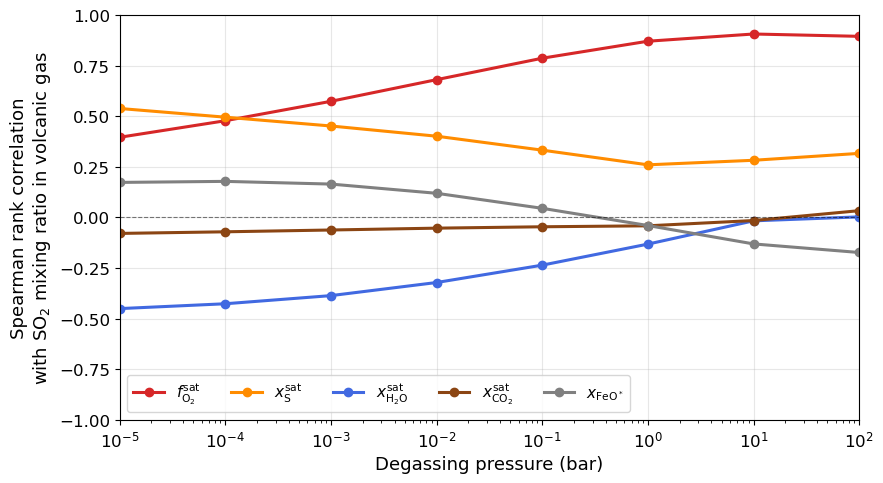

In [40]:
def plot_sensitivity(df, filename='figures/sensitivity_spearman.pdf'):
    """
    Spearman rank correlation of each input parameter with SO2 mixing ratio,
    computed separately at each pressure level. Shows which magma property
    most strongly controls whether volcanic gas is SO2-dominated.
    """
    import os
    from scipy.stats import spearmanr

    plt.rcParams.update({'font.size': 12})

    pressure_col = 'P_tot'
    so2_col = 'x_SO2_atm_input'

    params = [
        ('FMQ_sat',     r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$',       'tab:red'),
        ('mS_sat',      r'$x_{\mathrm{S}}^{\mathrm{sat}}$',         'darkorange'),
        ('mH2O_sat',    r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$',      'royalblue'),
        ('mCO2_sat',    r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$',      'saddlebrown'),
        ('FeO_star_wt', r'$x_{\mathrm{FeO^*}}$',                     'gray'),
    ]

    pressures = np.sort(df[pressure_col].dropna().unique())

    fig, ax = plt.subplots(figsize=(9, 5))

    for col, label, color in params:
        rhos = []
        P_valid = []
        for P in pressures:
            mask = np.isclose(df[pressure_col].values, P, atol=1e-12)
            sub = df.loc[mask, [col, so2_col]].dropna()
            if len(sub) < 100:
                continue
            rho, _ = spearmanr(sub[col].values, sub[so2_col].values)
            rhos.append(rho)
            P_valid.append(P)

        ax.plot(P_valid, rhos, 'o-', color=color, lw=2.2, ms=6, label=label)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Degassing pressure (bar)', fontsize=13)
    ax.set_ylabel('Spearman rank correlation\n' + r'with SO$_2$ mixing ratio in volcanic gas', fontsize=13)
    ax.set_ylim(-1, 1)
    ax.set_xlim(1e-5, 1e2)
    ax.legend(fontsize=11, loc='lower left', ncol=5)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_sensitivity(df)

### Solar system context: median SO$_2$ mixing ratio

Same fO$_2$ vs S/H$_2$O parameter space with solar system magma compositions overlaid, but now colored by the **median SO$_2$ mixing ratio** in each grid cell rather than the fraction exceeding a threshold. This removes the arbitrary 80% cutoff and shows the continuous landscape of SO$_2$ production across parameter space.

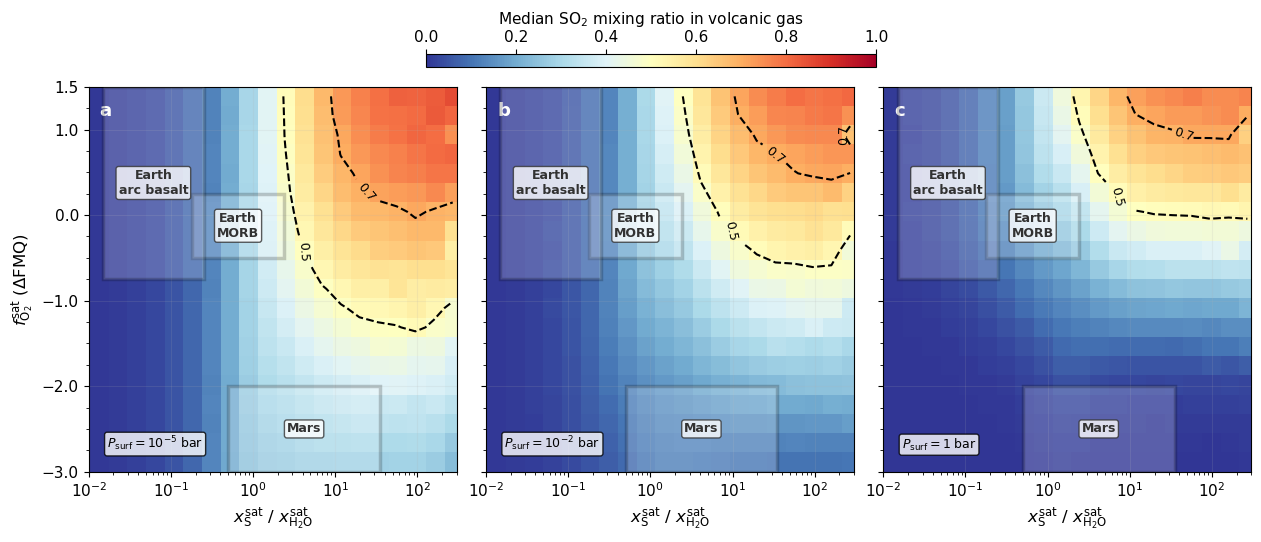

In [46]:
def plot_solar_system_context_median(df, pressures=(1e-5, 1e-2, 1e0),
                                     n_fO2_bins=20, n_ratio_bins=20,
                                     filename='figures/solar_system_context_median_so2.pdf'):
    """
    3-panel version: median SO2 mixing ratio in fO2 vs S/H2O space,
    one panel per pressure, with solar system magma compositions overlaid.
    """
    import os
    from matplotlib.patches import Rectangle
    from matplotlib.ticker import MultipleLocator

    plt.rcParams.update({'font.size': 11})

    pressure_col = 'P_tot'
    so2_col = 'x_SO2_atm_input'
    fO2_col = 'FMQ_sat'

    ratio = df['mS_sat'].values / df['mH2O_sat'].values

    fO2_edges = np.linspace(-3.0, 1.5, n_fO2_bins + 1)
    ratio_edges = np.logspace(np.log10(0.01), np.log10(350), n_ratio_bins + 1)
    ratio_ctrs = np.sqrt(ratio_edges[:-1] * ratio_edges[1:])
    fO2_ctrs = 0.5 * (fO2_edges[:-1] + fO2_edges[1:])
    R_mesh, F_mesh = np.meshgrid(ratio_ctrs, fO2_ctrs)

    # ── Solar system magma compositions ──────────────────────────────
    # Edit names, S/H2O ranges, and fO2 ranges here:
    solar_sys = [
        {'name': 'Earth\nMORB',
         'S_H2O_range': (0.18, 2.4), 'fO2_range': (-0.5, 0.25)},
        {'name': 'Earth\narc basalt',
         'S_H2O_range': (0.015, 0.25), 'fO2_range': (-0.75, 1.5)},
        {'name': 'Mars',
         'S_H2O_range': (0.5, 35.0), 'fO2_range': (-3.0, -2.0)},
    ]

    panel_labels = 'abc'

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    for idx, (ax, pressure_bar) in enumerate(zip(axes, pressures)):
        p_mask = np.isclose(df[pressure_col].values, pressure_bar, atol=1e-12)
        fO2_vals = df[fO2_col].values[p_mask]
        ratio_vals = ratio[p_mask]
        so2_vals = df[so2_col].values[p_mask]

        median_so2 = np.full((n_fO2_bins, n_ratio_bins), np.nan)
        for i in range(n_fO2_bins):
            for j in range(n_ratio_bins):
                mask = ((fO2_vals >= fO2_edges[i]) & (fO2_vals < fO2_edges[i+1]) &
                        (ratio_vals >= ratio_edges[j]) & (ratio_vals < ratio_edges[j+1]))
                n_total = np.sum(mask)
                if n_total >= 5:
                    median_so2[i, j] = np.median(so2_vals[mask])

        cf = ax.pcolormesh(R_mesh, F_mesh, median_so2,
                           cmap='RdYlBu_r', vmin=0, vmax=1,
                           shading='nearest', rasterized=True)

        med_filled = np.nan_to_num(median_so2, nan=0.0)
        cs = ax.contour(R_mesh, F_mesh, med_filled,
                        levels=[0.50, 0.70], colors='black',
                        linewidths=1.5, linestyles='--')
        ax.clabel(cs, fmt={0.50: '0.5', 0.70: '0.7'}, fontsize=9, inline=True)

        for body in solar_sys:
            s_lo, s_hi = body['S_H2O_range']
            f_lo, f_hi = body['fO2_range']
            rect = Rectangle((s_lo, f_lo), s_hi - s_lo, f_hi - f_lo,
                              linewidth=2.5, edgecolor='black',
                              facecolor='white', alpha=0.2, zorder=5)
            ax.add_patch(rect)
            cx = np.sqrt(s_lo * s_hi)
            cy = (f_lo + f_hi) / 2
            ax.text(cx, cy, body['name'], ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.8,
                              edgecolor='black', boxstyle='round,pad=0.2'))

        # Pressure label in bottom-left
        exp_P = int(np.round(np.log10(pressure_bar)))
        if exp_P == 0:
            p_str = r'$P_{\mathrm{surf}} = 1$ bar'
        else:
            p_str = rf'$P_{{\mathrm{{surf}}}} = 10^{{{exp_P}}}$ bar'
        ax.text(0.05, 0.06, p_str,
                transform=ax.transAxes, fontsize=9,
                color='black',
                bbox=dict(facecolor='white', alpha=0.8,
                          edgecolor='black', boxstyle='round,pad=0.2'))

        # Panel label in top-left
        ax.text(0.03, 0.96, panel_labels[idx],
                transform=ax.transAxes, ha='left', va='top',
                fontsize=13, fontweight='bold', color='white')

        ax.set_xscale('log')
        ax.set_xlim(1e-2, 300)
        ax.set_ylim(-3.0, 1.5)
        ax.set_yticks([-3, -2, -1, 0, 1, 1.5])
        ax.yaxis.set_minor_locator(MultipleLocator(0.25))
        ax.set_xlabel(r'$x_{\mathrm{S}}^{\mathrm{sat}}$ / $x_{\mathrm{H_2O}}^{\mathrm{sat}}$',
                      fontsize=12)
        ax.grid(alpha=0.15)

    axes[0].set_ylabel(r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ ($\Delta$FMQ)', fontsize=12)

    # Horizontal colorbar above the middle panel
    cbar_ax = fig.add_axes([0.35, 0.92, 0.30, 0.025])
    cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'Median SO$_2$ mixing ratio in volcanic gas', fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('top')

    plt.subplots_adjust(wspace=0.08)
    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_solar_system_context_median(df)

### How to get 80% SO2 in volcanic gas

Here we visualize the area of parameter space where 80% SO2 is achieved in the volcanic gases

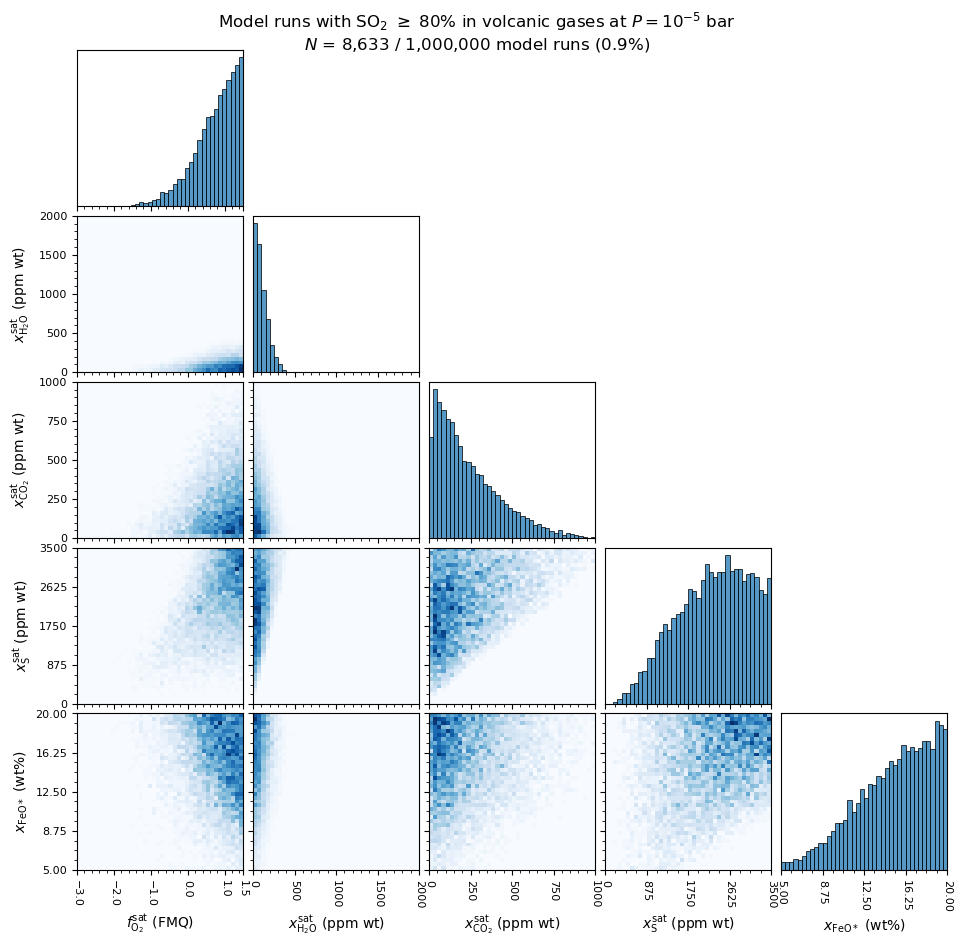

In [7]:
def plot_corner(df, xso2_threshold=0.80, pressure_bar=1e-5, show_prior=False,
                mode='square',
                scatter_max=5000, kde_max=5000,
                filename='figures/corner_so2_threshold.pdf'):
    """
    Corner plot of the 5 input parameters.

    Parameters
    ----------
    df : DataFrame
    xso2_threshold : float
    pressure_bar : float
    show_prior : bool
    mode : str
        'kde'      — kernel density estimate heatmap (default)
        'scatter'  — raw scatter points (subsampled to scatter_max)
        'hexbin'   — hexagonal bin density map
        'square'   — square bin (hist2d) density map
    scatter_max : int
    kde_max : int
    filename : str or None
    """
    import os
    from scipy.stats import gaussian_kde
    from matplotlib.ticker import AutoMinorLocator, MaxNLocator

    if mode not in ('kde', 'scatter', 'hexbin', 'square'):
        raise ValueError(f"mode must be 'kde', 'scatter', 'hexbin', or 'square'; got {mode!r}")

    plt.rcParams.update({'font.size': 11})

    pressure_col = 'P_tot'
    so2_col      = 'x_SO2_atm_input'

    # ── Parameter definitions (label, col, scale, limits, ticks) ─────
    # FMQ ticks include 1.0 explicitly
    params = [
        (r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ (FMQ)',
         'FMQ_sat',      1.0,   (-3.0, 1.5),  [-3, -2, -1, 0, 1.0, 1.5]),
        (r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$ (ppm wt)',
         'mH2O_sat',     1e6,   (0, 2000),    [0, 500, 1000, 1500, 2000]),
        (r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$ (ppm wt)',
         'mCO2_sat',     1e6,   (0, 1000),    [0, 250, 500, 750, 1000]),
        (r'$x_{\mathrm{S}}^{\mathrm{sat}}$ (ppm wt)',
         'mS_sat',       1e6,   (0, 3500),    [0, 875, 1750, 2625, 3500]),
        (r'$x_{\mathrm{FeO*}}$ (wt%)',
         'FeO_star_wt',  100.0, (5.0, 20.0),  [5, 8.75, 12.5, 16.25, 20]),
    ]
    N = len(params)

    # ── Slice data ────────────────────────────────────────────────────
    p_mask   = np.isclose(df[pressure_col].values, pressure_bar, rtol=0.0, atol=1e-12)
    df_p     = df.loc[p_mask]
    so2_vals = df_p[so2_col].values
    hi_mask  = np.isfinite(so2_vals) & (so2_vals >= xso2_threshold)
    df_hi    = df_p.loc[hi_mask]

    n_all, n_hi = len(df_p), len(df_hi)

    def arr(df_sub, col, scale):
        return df_sub[col].values * scale

    all_data = [arr(df_p,  col, sc) for _, col, sc, _, _ in params]
    hi_data  = [arr(df_hi, col, sc) for _, col, sc, _, _ in params]

    rng = np.random.default_rng(0)
    if mode == 'scatter' and n_hi > scatter_max:
        sub_idx = rng.choice(n_hi, size=scatter_max, replace=False)
        hi_plot = [d[sub_idx] for d in hi_data]
    elif mode == 'kde' and n_hi > kde_max:
        sub_idx = rng.choice(n_hi, size=kde_max, replace=False)
        hi_plot = [d[sub_idx] for d in hi_data]
    else:
        hi_plot = hi_data

    # ── Figure ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(N, N, figsize=(10, 10))
    fig.subplots_adjust(hspace=0.06, wspace=0.06,
                        left=0.10, right=0.97, top=0.94, bottom=0.12)

    n_bins  = 40
    kde_res = 80

    for row in range(N):
        lbl_r, _, _, lim_r, ticks_r = params[row]
        for c in range(N):
            ax = axes[row, c]
            lbl_c, _, _, lim_c, ticks_c = params[c]

            if c > row:
                ax.set_visible(False)
                continue

            bins_r = np.linspace(*lim_r, n_bins + 1)
            bins_c = np.linspace(*lim_c, n_bins + 1)

            if c == row:
                # ── Diagonal: 1D count histograms ─────────────────
                if show_prior:
                    ax.hist(all_data[row], bins=bins_r,
                            color='0.80', zorder=1,
                            edgecolor='black', linewidth=0.7)
                ax.hist(hi_data[row], bins=bins_r,
                        color='tab:blue', alpha=0.75, zorder=2,
                        edgecolor='black', linewidth=0.7)
                ax.set_xlim(*lim_r)
                ax.set_xticks(ticks_r)
                ax.set_yticks([])
                ax.xaxis.set_minor_locator(AutoMinorLocator())

            elif mode == 'scatter':
                if show_prior:
                    ax.scatter(all_data[c], all_data[row],
                               s=1, color='0.80', alpha=0.3, zorder=1,
                               rasterized=True)
                ax.scatter(hi_plot[c], hi_plot[row],
                           s=2, color='tab:blue', alpha=0.4, zorder=2,
                           rasterized=True)
                ax.set_xlim(*lim_c); ax.set_ylim(*lim_r)
                ax.set_xticks(ticks_c); ax.set_yticks(ticks_r)
                ax.xaxis.set_minor_locator(AutoMinorLocator())
                ax.yaxis.set_minor_locator(AutoMinorLocator())

            elif mode == 'hexbin':
                if show_prior:
                    ax.hexbin(all_data[c], all_data[row],
                              gridsize=30, cmap='Greys', mincnt=1,
                              linewidths=0,
                              extent=[*lim_c, *lim_r], zorder=1)
                ax.hexbin(hi_data[c], hi_data[row],
                          gridsize=30, cmap='Blues', mincnt=1,
                          linewidths=0,
                          extent=[*lim_c, *lim_r], zorder=2)
                ax.set_xlim(*lim_c); ax.set_ylim(*lim_r)
                ax.set_xticks(ticks_c); ax.set_yticks(ticks_r)
                ax.xaxis.set_minor_locator(AutoMinorLocator())
                ax.yaxis.set_minor_locator(AutoMinorLocator())

            elif mode == 'square':
                # ── Square bin (hist2d) ───────────────────────────
                if show_prior:
                    ax.hist2d(all_data[c], all_data[row],
                              bins=[bins_c, bins_r], cmap='Greys',
                              zorder=1)
                ax.hist2d(hi_data[c], hi_data[row],
                          bins=[bins_c, bins_r], cmap='Blues',
                          zorder=2)
                ax.set_xlim(*lim_c); ax.set_ylim(*lim_r)
                ax.set_xticks(ticks_c); ax.set_yticks(ticks_r)
                ax.xaxis.set_minor_locator(AutoMinorLocator())
                ax.yaxis.set_minor_locator(AutoMinorLocator())

            else:
                # ── KDE heatmap ───────────────────────────────────
                xg = np.linspace(*lim_c, kde_res)
                yg = np.linspace(*lim_r, kde_res)
                Xg, Yg = np.meshgrid(xg, yg)
                pts = np.vstack([hi_plot[c], hi_plot[row]])
                try:
                    kde = gaussian_kde(pts)
                    Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(kde_res, kde_res)
                except Exception:
                    Z = np.zeros((kde_res, kde_res))

                ax.imshow(Z, origin='lower', aspect='auto',
                          extent=[*lim_c, *lim_r],
                          cmap='Blues', interpolation='bilinear', zorder=2)
                ax.set_xlim(*lim_c); ax.set_ylim(*lim_r)
                ax.set_xticks(ticks_c); ax.set_yticks(ticks_r)
                ax.xaxis.set_minor_locator(AutoMinorLocator())
                ax.yaxis.set_minor_locator(AutoMinorLocator())

            # ── Tick / label visibility ───────────────────────────
            if row == N - 1:
                ax.set_xlabel(lbl_c, fontsize=10, labelpad=4)
                ax.tick_params(axis='x', labelsize=8, rotation=-90)
            else:
                ax.tick_params(axis='x', labelbottom=False)

            if c == 0 and row > 0:
                ax.set_ylabel(lbl_r, fontsize=10, labelpad=4)
                ax.tick_params(axis='y', labelsize=8)
            else:
                ax.tick_params(axis='y', labelleft=False)

    # ── Title ─────────────────────────────────────────────────────────
    mode_label = {'kde':     f'KDE heatmap (fit on N≤{kde_max})',
                  'scatter': f'scatter (N≤{scatter_max})',
                  'hexbin':  'hexbin density',
                  'square':  'square bin density'}[mode]
    _exp = int(np.round(np.log10(pressure_bar)))
    fig.suptitle(
        rf'Model runs with SO$_2$ $\geq$ {xso2_threshold*100:.0f}% in volcanic gases at $P = 10^{{{_exp}}}$ bar'
        f'\n'
        rf'$N$ = {n_hi:,} / {n_all:,} model runs ({100*n_hi/n_all:.1f}%)',
        fontsize=12,
    )

    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_corner(df, xso2_threshold=0.80, pressure_bar=1e-5, mode='square')


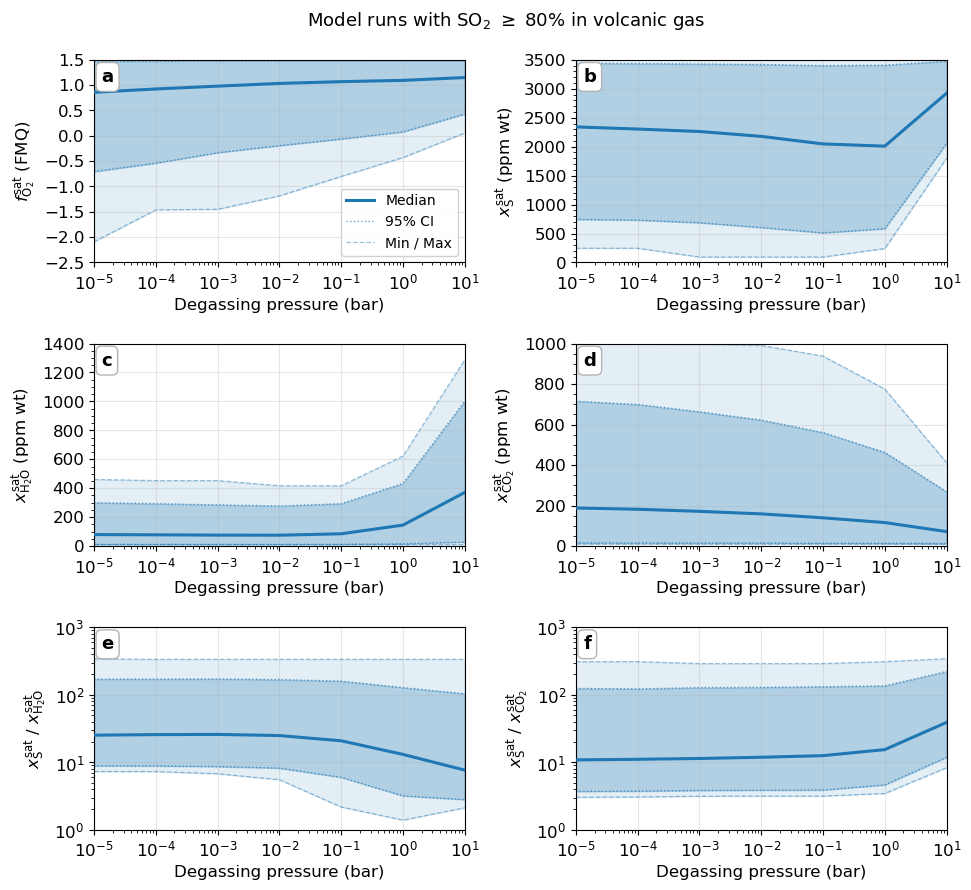

In [8]:
def plot_vars_vs_pressure(df, xso2_threshold=0.80,
                         fO2_min=None, fO2_max=None,
                         show_feo=False,
                         filename='figures/fO2_vs_pressure.pdf'):
    """
    3×2 panel figure (or 4-row with FeO* if show_feo=True):
    fO2, xS, xH2O, xCO2, xS/xH2O, xS/xCO2 [, FeO*]
    required to produce SO2 >= xso2_threshold.

    Parameters
    ----------
    df : DataFrame
    xso2_threshold : float
    fO2_min, fO2_max : float or None
    show_feo : bool
        If True, adds a 7th panel (FeO*) in the bottom-left position.
    filename : str or None
    """
    import os
    from matplotlib.lines import Line2D
    from matplotlib.ticker import AutoMinorLocator
    from matplotlib.gridspec import GridSpec

    plt.rcParams.update({'font.size': 12})

    pressure_col = 'P_tot'
    so2_col      = 'x_SO2_atm_input'
    color        = 'tab:blue'

    df_filt = df.copy()
    if fO2_min is not None:
        df_filt = df_filt.loc[df_filt['FMQ_sat'] >= fO2_min]
    if fO2_max is not None:
        df_filt = df_filt.loc[df_filt['FMQ_sat'] <= fO2_max]

    pressures = np.sort(df_filt[pressure_col].dropna().unique())

    scalar_keys = [('FMQ_sat', 1.0), ('mS_sat', 1e6), ('mH2O_sat', 1e6), ('mCO2_sat', 1e6)]
    if show_feo:
        scalar_keys.append(('FeO_star_wt', 100.0))
    ratio_keys  = ['S_over_H2O', 'S_over_CO2']
    all_keys    = [k for k, _ in scalar_keys] + ratio_keys

    P_valid = []
    stats = {key: {'lo': [], 'med': [], 'hi': [], 'p2_5': [], 'p97_5': []}
             for key in all_keys}

    for P in pressures:
        mask = (df_filt[pressure_col] == P) & (df_filt[so2_col] >= xso2_threshold)
        sub  = df_filt.loc[mask]
        if len(sub) == 0:
            continue
        P_valid.append(P)
        for key, scale in scalar_keys:
            vals = sub[key].values * scale
            vals = vals[np.isfinite(vals)]
            stats[key]['lo'].append(np.min(vals))
            stats[key]['med'].append(np.median(vals))
            stats[key]['hi'].append(np.max(vals))
            stats[key]['p2_5'].append(np.percentile(vals, 2.5))
            stats[key]['p97_5'].append(np.percentile(vals, 97.5))
        for rkey, num, den in [('S_over_H2O', 'mS_sat', 'mH2O_sat'),
                                ('S_over_CO2', 'mS_sat', 'mCO2_sat')]:
            vals = sub[num].values / sub[den].values
            vals = vals[np.isfinite(vals) & (vals > 0)]
            stats[rkey]['lo'].append(np.min(vals))
            stats[rkey]['med'].append(np.median(vals))
            stats[rkey]['hi'].append(np.max(vals))
            stats[rkey]['p2_5'].append(np.percentile(vals, 2.5))
            stats[rkey]['p97_5'].append(np.percentile(vals, 97.5))

    P_valid = np.array(P_valid)

    def _arr(key, stat):
        return np.array(stats[key][stat])

    # ── Figure layout ─────────────────────────────────────────────────
    n_rows = 4 if show_feo else 3
    fig_h  = 13 if show_feo else 10
    fig    = plt.figure(figsize=(11, fig_h))
    gs     = GridSpec(n_rows, 2, figure=fig, hspace=0.4, wspace=0.3)
    axes   = np.array([[fig.add_subplot(gs[r, c]) for c in range(2)]
                       for r in range(3)])
    ax_feo = fig.add_subplot(gs[3, 0]) if show_feo else None

    # Build title from active filters
    so2_pct = int(xso2_threshold * 100)
    title = f'Model runs with SO$_2$ $\\geq$ {so2_pct}% in volcanic gas'
    if fO2_min is not None and fO2_max is not None:
        title += f',  FMQ $\\in$ [{fO2_min}, {fO2_max}]'
    elif fO2_min is not None:
        title += f',  FMQ $\\geq$ {fO2_min}'
    elif fO2_max is not None:
        title += f',  FMQ $\\leq$ {fO2_max}'
    fig.suptitle(title, fontsize=13, y=0.93)

    panel_cfg = [
        dict(ax=axes[0, 0], key='FMQ_sat',
             ylabel=r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ (FMQ)',
             ylim=(-2.5, 1.5), yticks=np.arange(-2.5, 2.0, 0.5),
             log_y=False, minor_ticks=False, label='a'),
        dict(ax=axes[0, 1], key='mS_sat',
             ylabel=r'$x_{\mathrm{S}}^{\mathrm{sat}}$ (ppm wt)',
             ylim=(0, 3500), yticks=np.arange(0, 3501, 500),
             log_y=False, minor_ticks=True, label='b'),
        dict(ax=axes[1, 0], key='mH2O_sat',
             ylabel=r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$ (ppm wt)',
             ylim=(0, 1400), yticks=np.arange(0, 1401, 200),
             log_y=False, minor_ticks=True, label='c'),
        dict(ax=axes[1, 1], key='mCO2_sat',
             ylabel=r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$ (ppm wt)',
             ylim=(0, 1000), yticks=np.arange(0, 1001, 200),
             log_y=False, minor_ticks=True, label='d'),
        dict(ax=axes[2, 0], key='S_over_H2O',
             ylabel=r'$x_{\mathrm{S}}^{\mathrm{sat}}$ / $x_{\mathrm{H_2O}}^{\mathrm{sat}}$',
             ylim=(1e0, 1e3), yticks=None,
             log_y=True, minor_ticks=False, label='e'),
        dict(ax=axes[2, 1], key='S_over_CO2',
             ylabel=r'$x_{\mathrm{S}}^{\mathrm{sat}}$ / $x_{\mathrm{CO_2}}^{\mathrm{sat}}$',
             ylim=(1e0, 1e3), yticks=None,
             log_y=True, minor_ticks=False, label='f'),
    ]

    _lbl_bbox = dict(facecolor='white', edgecolor='0.7', alpha=1.0, boxstyle='round,pad=0.3')

    def _draw_panel(ax, key, ylabel, ylim, yticks, log_y, minor_ticks, label):
        lo    = _arr(key, 'lo')
        med   = _arr(key, 'med')
        hi    = _arr(key, 'hi')
        p2_5  = _arr(key, 'p2_5')
        p97_5 = _arr(key, 'p97_5')

        ax.fill_between(P_valid, lo, hi, alpha=0.12, color=color)
        ax.plot(P_valid, lo,    color=color, lw=0.9, ls='--', alpha=0.45)
        ax.plot(P_valid, hi,    color=color, lw=0.9, ls='--', alpha=0.45)
        ax.fill_between(P_valid, p2_5, p97_5, alpha=0.25, color=color)
        ax.plot(P_valid, p2_5,  color=color, lw=1.0, ls=':', alpha=0.7)
        ax.plot(P_valid, p97_5, color=color, lw=1.0, ls=':', alpha=0.7)
        ax.plot(P_valid, med,   color=color, lw=2.2, zorder=3)

        ax.set_xscale('log')
        if log_y:
            ax.set_yscale('log')
        ax.set_xlim(1e-5, 1e1)
        ax.set_ylim(bottom=ylim[0], top=ylim[1])
        if yticks is not None:
            ax.set_yticks(yticks)
        if minor_ticks:
            ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.set_xlabel('Degassing pressure (bar)', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(alpha=0.3)
        ax.text(0.02, 0.96, label, transform=ax.transAxes,
                ha='left', va='top', fontsize=13, fontweight='bold', bbox=_lbl_bbox)

    for cfg in panel_cfg:
        _draw_panel(**{k: v for k, v in cfg.items() if k != 'ax'}, ax=cfg['ax'])

    if show_feo:
        _draw_panel(ax=ax_feo, key='FeO_star_wt',
                    ylabel=r'FeO$^*$ (wt%)',
                    ylim=(5, 20), yticks=np.arange(5, 21, 2.5),
                    log_y=False, minor_ticks=True, label='g')

    legend_handles = [
        Line2D([0], [0], color=color, lw=2.2, label='Median'),
        Line2D([0], [0], color=color, lw=1.0, ls=':', alpha=0.7, label='95% CI'),
        Line2D([0], [0], color=color, lw=0.9, ls='--', alpha=0.45, label='Min / Max'),
    ]
    axes[0, 0].legend(handles=legend_handles, loc='lower right', fontsize=10, framealpha=0.9)

    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_vars_vs_pressure(df, 0.8, None, None, show_feo=False)


### Option A: Partial dependence plots

For each input parameter, show the running median of SO$_2$, H$_2$O, and CO$_2$ mixing ratios as a function of that parameter. Separate lines for each pressure level reveal how the dependence shifts with degassing pressure.

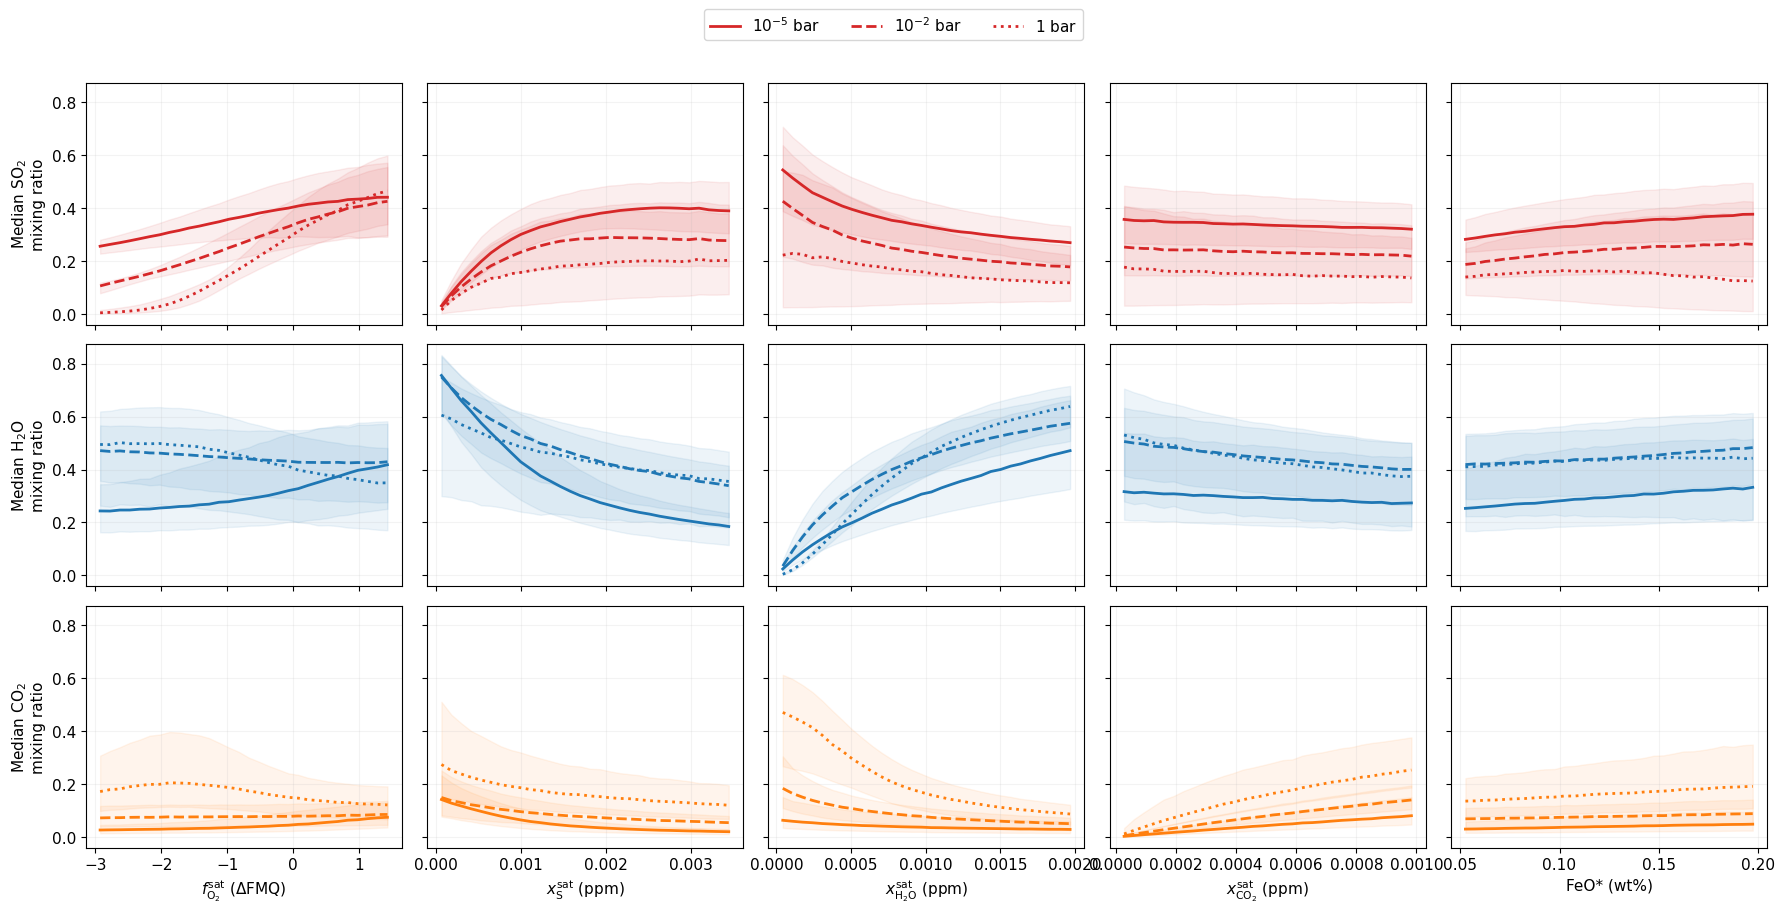

In [33]:
def plot_partial_dependence(df, pressures=(1e-5, 1e-2, 1e0), n_bins=30,
                           filename='figures/partial_dependence.pdf'):
    """
    Partial dependence plots: median SO2, H2O, CO2 mixing ratio
    vs each input parameter, with one line per pressure.
    """
    import os

    plt.rcParams.update({'font.size': 11})

    input_params = [
        ('FMQ_sat', r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ ($\Delta$FMQ)', 'linear'),
        ('mS_sat', r'$x_{\mathrm{S}}^{\mathrm{sat}}$ (ppm)', 'linear'),
        ('mH2O_sat', r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$ (ppm)', 'linear'),
        ('mCO2_sat', r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$ (ppm)', 'linear'),
        ('FeO_star_wt', r'FeO* (wt%)', 'linear'),
    ]

    species = [
        ('x_SO2_atm_input', r'SO$_2$', 'C3'),
        ('x_H2O_atm_input', r'H$_2$O', 'C0'),
        ('x_CO2_atm_input', r'CO$_2$', 'C1'),
    ]

    pressure_styles = {
        1e-5: ('-', r'$10^{-5}$ bar'),
        1e-2: ('--', r'$10^{-2}$ bar'),
        1e0:  (':', r'$1$ bar'),
    }

    fig, axes = plt.subplots(len(species), len(input_params),
                             figsize=(18, 9), sharex='col', sharey=True)

    for j, (param_col, param_label, scale) in enumerate(input_params):
        param_vals = df[param_col].values

        if scale == 'log':
            edges = np.logspace(np.log10(param_vals.min()), np.log10(param_vals.max()), n_bins + 1)
            centers = np.sqrt(edges[:-1] * edges[1:])
        else:
            edges = np.linspace(param_vals.min(), param_vals.max(), n_bins + 1)
            centers = 0.5 * (edges[:-1] + edges[1:])

        for i, (sp_col, sp_label, sp_color) in enumerate(species):
            ax = axes[i, j]

            for pressure_bar in pressures:
                p_mask = np.isclose(df['P_tot'].values, pressure_bar, atol=1e-12)
                sp_vals = df[sp_col].values

                medians = np.full(n_bins, np.nan)
                q25 = np.full(n_bins, np.nan)
                q75 = np.full(n_bins, np.nan)
                for k in range(n_bins):
                    mask = p_mask & (param_vals >= edges[k]) & (param_vals < edges[k+1])
                    if np.sum(mask) >= 10:
                        medians[k] = np.median(sp_vals[mask])
                        q25[k] = np.percentile(sp_vals[mask], 25)
                        q75[k] = np.percentile(sp_vals[mask], 75)

                ls, p_label = pressure_styles[pressure_bar]
                valid = ~np.isnan(medians)
                ax.plot(centers[valid], medians[valid], ls=ls, color=sp_color,
                        lw=2, label=p_label if i == 0 and j == 0 else None)
                ax.fill_between(centers[valid], q25[valid], q75[valid],
                                color=sp_color, alpha=0.08)

            if scale == 'log':
                ax.set_xscale('log')
            ax.grid(alpha=0.15)

            if i == len(species) - 1:
                ax.set_xlabel(param_label, fontsize=11)
            if j == 0:
                ax.set_ylabel(f'Median {sp_label}\nmixing ratio', fontsize=11)

    # Single legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=11,
               frameon=True, bbox_to_anchor=(0.5, 1.02))

    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.08, wspace=0.08)
    if filename:
        os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_partial_dependence(df)